This notebook aggregates the individual taxi trips into hourly taxi demand per pickup location.

In [211]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

In [212]:
data = pl.read_parquet("../data/02/02_merged_data.parquet").rename({"trip_start": "bin_15m", 'pickup_community_area': 'community_area', 'pickup_census_tract': 'census_tract'})
display(data.shape)
display(data.head())

(13505728, 57)

trip_id,taxi_id,bin_15m,trip_end,trip_seconds,trip_miles,census_tract,dropoff_census_tract,community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,i8
"""158715fbdd80e57020cf0ec7f20b96…","""325822c24b90e28594c09e37bef346…",2024-01-01 00:30:00 CST,2024-01-01 00:41:29 CST,11m 29s,2.75,null,null,21,14,9.32,4.0,0.0,0.0,13.32,"""mobile""","""sun taxi""",41.938666,-87.711211,41.968069,-87.721559,14.36865,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""9edd4c912980e36ec79f59e07d24d1…","""57fa54b44d1e25d82c1de3200158c2…",2024-01-01 00:00:00 CST,2024-01-01 00:12:06 CST,12m 6s,4.01,null,null,8,24,13.25,2.75,0.0,0.0,16.5,"""credit card""","""sun taxi""",41.899602,-87.633308,41.901207,-87.676356,19.884298,0,1,1,false,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""3d656effd32f675fe4771d8b1047ae…","""18332569daad955f48c8d965fe85ef…",2024-01-01 00:45:00 CST,2024-01-01 00:48:23 CST,3m 23s,0.66,null,null,6,3,5.0,3.0,0.0,0.0,8.5,"""credit card""","""chicago independents""",41.944227,-87.655998,41.965812,-87.655879,11.704433,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""e9a0eeffcb2ec066e5b39c6c7932a1…","""d1b8521ed4784a33ed7be8ad0a1731…",2024-01-01 00:45:00 CST,2024-01-01 00:55:59 CST,10m 59s,5.69,null,null,3,8,16.5,0.0,0.0,1.0,17.5,"""cash""","""5 star taxi""",41.965812,-87.655879,41.899602,-87.633308,31.08346,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""d14abd8e6addce6dda49f16f4d6957…","""da1ddce066f7f02d7f134cb4b049fa…",2024-01-01 00:00:00 CST,2024-01-01 01:05:59 CST,1h 5m 59s,16.42,null,null,56,6,50.5,9.15,0.0,10.0,70.15,"""credit card""","""5 star taxi""",41.792592,-87.769615,41.944227,-87.655998,14.931043,0,1,1,false,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1


# Trip Aggregation
We previously aggregated a lot of data for the temporal spatial analysis. To use this we do the following:
1. Create a list of trips for census tract and community level 
2. Aggregate the lists to census tract/community for the time buckets 1h, 4h and 1d
3. Select the additional data and drop duplicates
4. Merge both datasets
5. Merge POI data
6. Merge Centroid data

We keep in mind, that the census tract includes a lot of missing values, therefore we must drop the missing records first. The result is that we have less than half of the records for the census tract aggregation.

In [213]:
print("Total number of records:", data.shape[0])

Total number of records: 13505728


## 1. Create list of trips for census tract and community level
### Census Tract

In [214]:
trips_census = data.select(['census_tract', 'bin_1h', 'bin_4h', 'bin_1d'])
print("Number of unique census tracts:", trips_census['census_tract'].n_unique())
print("Number of missing values in census tracts:", trips_census['census_tract'].null_count())
print("Percentage of missing values in census tracts:", round(trips_census['census_tract'].null_count() / trips_census.shape[0] * 100, 2), "%")
trips_census = trips_census.drop_nulls()
print("Number of records after dropping missing values in census tracts:", trips_census.shape[0])

Number of unique census tracts: 474
Number of missing values in census tracts: 7399844
Percentage of missing values in census tracts: 54.79 %
Number of records after dropping missing values in census tracts: 6105884


### Community Level

In [215]:
trips_community = data.select(['community_area', 'bin_1h', 'bin_4h', 'bin_1d'])
print("Number of unique community areas:", trips_community['community_area'].n_unique())
print("Number of missing values in community areas:", trips_community['community_area'].null_count())
print("Percentage of missing values in community areas:", round(trips_community['community_area'].null_count() / trips_community.shape[0] * 100, 2), "%")
trips_community = trips_community.drop_nulls()
print("Number of records after dropping missing values in community areas:", trips_community.shape[0])

Number of unique community areas: 77
Number of missing values in community areas: 0
Percentage of missing values in community areas: 0.0 %
Number of records after dropping missing values in community areas: 13505728


## 2. Aggregate the lists to census tract/community for the time buckets 1h, 4h and 1d

### Census Tract

In [216]:
trips_census_agg_1h = trips_census.group_by(['census_tract', 'bin_1h']).agg(pl.len().alias('trip_count')).sort('bin_1h')
trips_census_agg_4h = trips_census.group_by(['census_tract', 'bin_4h']).agg(pl.len().alias('trip_count')).sort('bin_4h')
trips_census_agg_1d = trips_census.group_by(['census_tract', 'bin_1d']).agg(pl.len().alias('trip_count')).sort('bin_1d')
print("Example of aggregated trips (1h):")
display(trips_census_agg_1h.head(2))

print('Number of bins (unique bin_1h, census tract values):', trips_census_agg_1h[['bin_1h', 'census_tract']].n_unique())
print('Number of bins (unique bin_4h, census tract values):', trips_census_agg_4h[['bin_4h', 'census_tract']].n_unique())
print('Number of bins (unique bin_1d, census tract values):', trips_census_agg_1d[['bin_1d', 'census_tract']].n_unique())

Example of aggregated trips (1h):


census_tract,bin_1h,trip_count
i64,"datetime[ms, America/Chicago]",u32
17031071500,2024-01-01 00:00:00 CST,1
17031980000,2024-01-01 00:00:00 CST,10


Number of bins (unique bin_1h, census tract values): 388310
Number of bins (unique bin_4h, census tract values): 156286
Number of bins (unique bin_1d, census tract values): 53903


Below you can see distribution plots about the aggregated data. So you can see how frequent it is that a specific count of trips in a census in a 1h/4h/1d bin is.

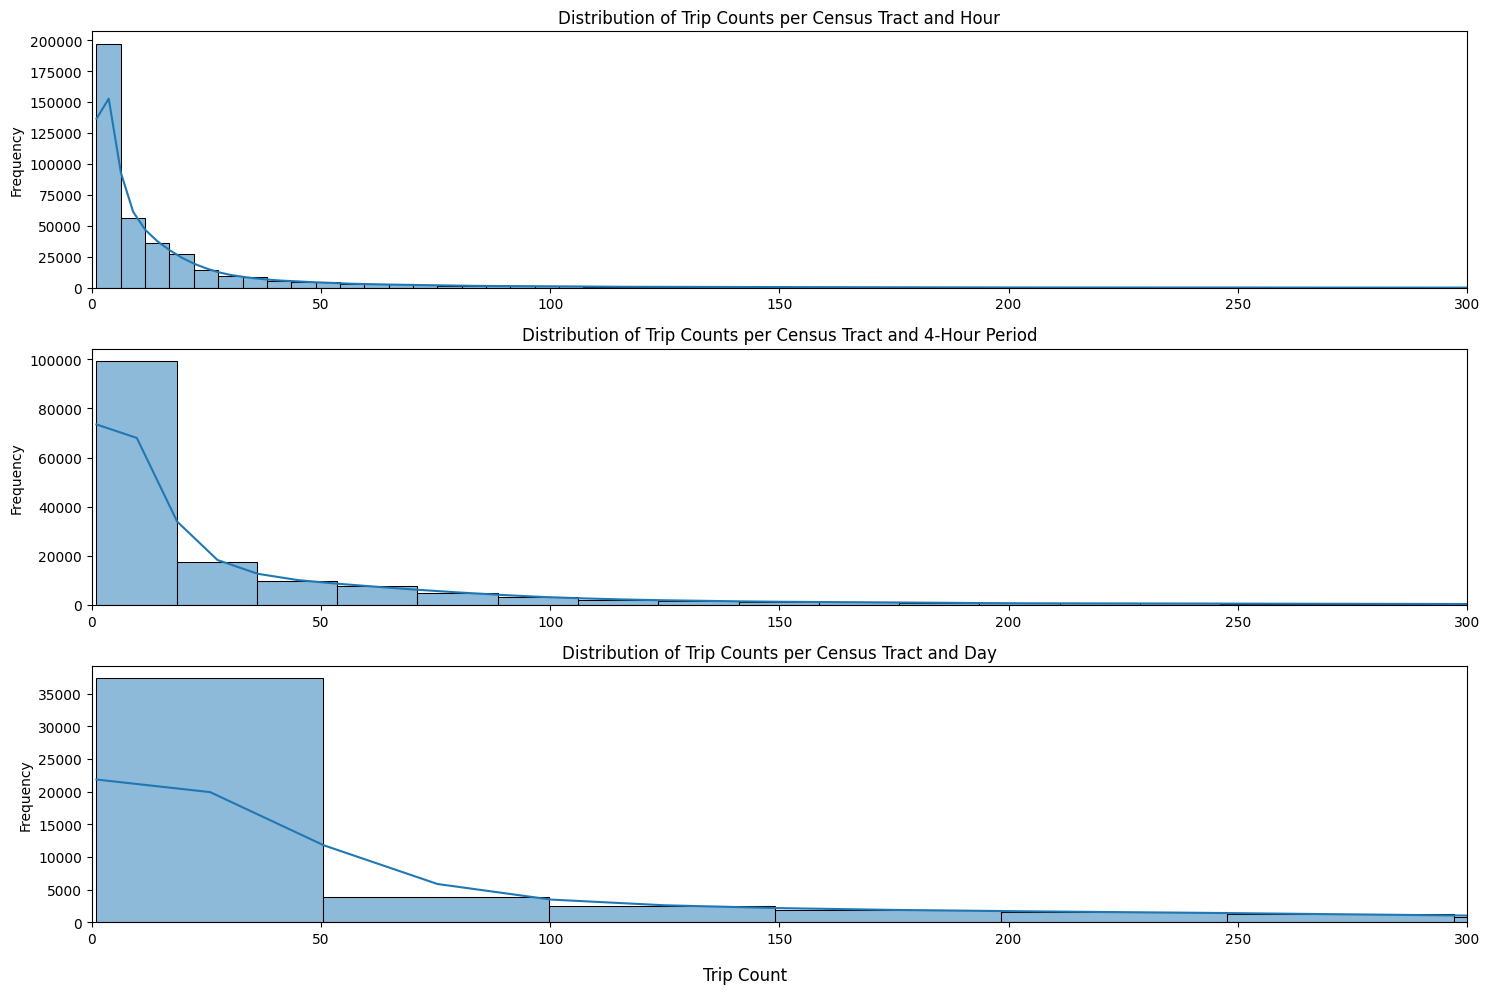

In [217]:
# plot distribution of trip counts
fig, ax = plt.subplots(3, 1, figsize=(15, 10))
sns.histplot(trips_census_agg_1h['trip_count'], bins=100, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Trip Counts per Census Tract and Hour')
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 300)
sns.histplot(trips_census_agg_4h['trip_count'], bins=100, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Trip Counts per Census Tract and 4-Hour Period')
ax[1].set_xlabel('')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 300)
sns.histplot(trips_census_agg_1d['trip_count'], bins=100, kde=True, ax=ax[2])
ax[2].set_title('Distribution of Trip Counts per Census Tract and Day')
ax[2].set_xlabel('')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 300)
# single shared x-axis label at the very bottom for all three panels
fig.supxlabel('Trip Count')
plt.tight_layout()
plt.show()

### Community area

In [218]:
trips_community_agg_1h = trips_community.group_by(['community_area', 'bin_1h']).agg(pl.len().alias('trip_count')).sort('bin_1h')
trips_community_agg_4h = trips_community.group_by(['community_area', 'bin_4h']).agg(pl.len().alias('trip_count')).sort('bin_4h')
trips_community_agg_1d = trips_community.group_by(['community_area', 'bin_1d']).agg(pl.len().alias('trip_count')).sort('bin_1d')
print("Example of aggregated trips (1h):")
display(trips_community_agg_1h.head(2))

print('Number of bins (unique bin_1h, community area values):', trips_community_agg_1h[['bin_1h', 'community_area']].n_unique())
print('Number of bins (unique bin_4h, community area values):', trips_community_agg_4h[['bin_4h', 'community_area']].n_unique())
print('Number of bins (unique bin_1d, community area values):', trips_community_agg_1d[['bin_1d', 'community_area']].n_unique())

Example of aggregated trips (1h):


community_area,bin_1h,trip_count
i64,"datetime[ms, America/Chicago]",u32
24,2024-01-01 00:00:00 CST,22
38,2024-01-01 00:00:00 CST,1


Number of bins (unique bin_1h, community area values): 884599
Number of bins (unique bin_4h, community area values): 318806
Number of bins (unique bin_1d, community area values): 65015


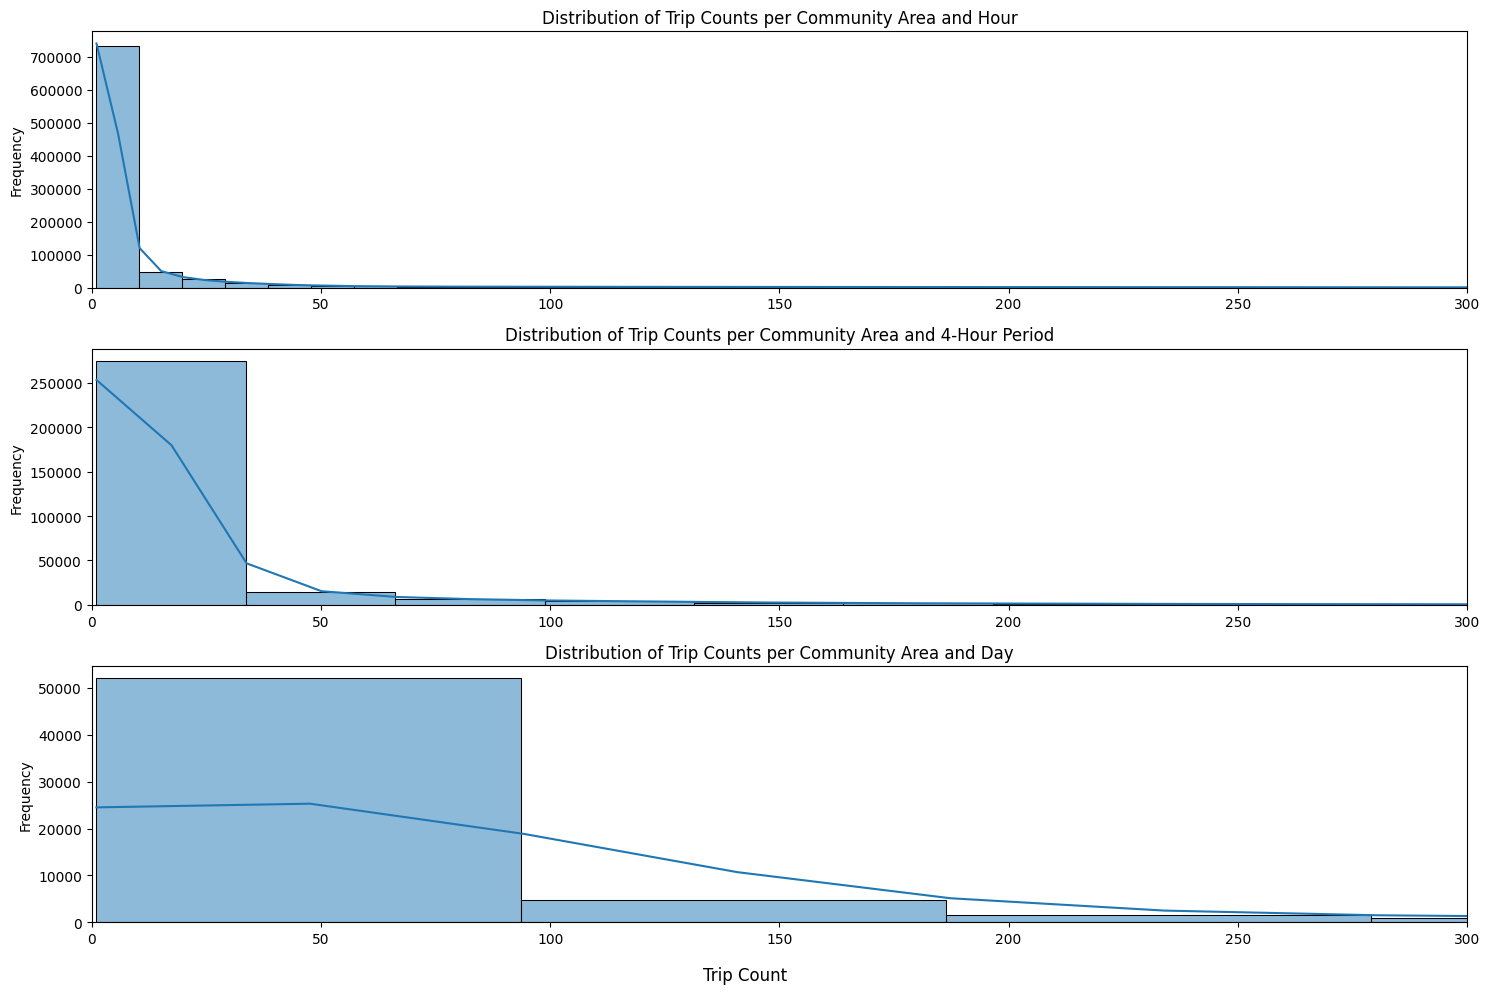

In [219]:
# plot distribution of trip counts
fig, ax = plt.subplots(3, 1, figsize=(15, 10))
sns.histplot(trips_community_agg_1h['trip_count'], bins=100, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Trip Counts per Community Area and Hour')
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 300)
sns.histplot(trips_community_agg_4h['trip_count'], bins=100, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Trip Counts per Community Area and 4-Hour Period')
ax[1].set_xlabel('')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 300)
sns.histplot(trips_community_agg_1d['trip_count'], bins=100, kde=True, ax=ax[2])
ax[2].set_title('Distribution of Trip Counts per Community Area and Day')
ax[2].set_xlabel('')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 300)
# single shared x-axis label at the very bottom for all three panels
fig.supxlabel('Trip Count')
plt.tight_layout()
plt.show()

## 3. Select the additional data and drop duplicates
As we already merged the additional data previously, we can now just select it, drop duplicates and merge it back in.

### Previously aggregated data
Other irrelevant location columns are dropped. Furthermore columns which are duplicate are also dropped, e.g. is_weekend is already included as DayOfWeek_Saturday/Sunday. Below you can see the selected columns.

In [220]:
data.columns

['trip_id',
 'taxi_id',
 'bin_15m',
 'trip_end',
 'trip_seconds',
 'trip_miles',
 'census_tract',
 'dropoff_census_tract',
 'community_area',
 'dropoff_community_area',
 'fare_usd',
 'tips_usd',
 'tolls_usd',
 'extras_usd',
 'trip_total_usd',
 'payment_type',
 'company',
 'pickup_lat',
 'pickup_lon',
 'dropoff_lat',
 'dropoff_lon',
 'average_speed_mph',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'bin_30min',
 'bin_1h',
 'bin_4h',
 'bin_1d',
 'bin_1w',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'date_day',
 'DayOfWeek_Friday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'BankHoliday',
 'CorporateHoliday',
 'CityHoliday',
 'StateHoliday',
 'temperature_c',
 'rain_mm',
 'snowfall_mm',
 'wind_speed_kmh',
 'temperature_max_c',
 'temperature_min_c',
 'rain',
 'strong_rain',
 'snow',
 'wind',
 'strong_wind']

In [221]:
base_columns = [
 'hour_sin', 'hour_cos',
 'month_sin', 'month_cos',
 'DayOfWeek_Friday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday',
 'BankHoliday', 'CorporateHoliday', 'CityHoliday', 'StateHoliday', 
 'rain', 'strong_rain', 'snow', 'wind', 'strong_wind',
 'temperature_c', 'temperature_max_c', 'temperature_min_c']
additional_data_1h = data.select(['bin_1h'] + base_columns).unique(subset=['bin_1h'])
additional_data_4h = data.select(['bin_4h'] + base_columns).unique(subset=['bin_4h'])
additional_data_1d = data.select(['bin_1d'] + base_columns).unique(subset=['bin_1d'])

print('Example of 1-hour additional data')
additional_data_1h.head(2)

Example of 1-hour additional data


bin_1h,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
"datetime[ms, America/Chicago]",f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
2025-04-22 22:00:00 CDT,-0.5,0.866025,0.866025,-0.5,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,16.9,20.65,5.95
2026-03-05 19:00:00 CST,-0.965926,0.258819,1.0,6.1232e-17,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,4.6,19.85,4.9


To ensure that no duplicates are left, we check the bin_1h and calculate some statistics which show that the times are about to match with some gaps.

In [222]:
additional_data_agg_1h = additional_data_1h.group_by(['bin_1h']).agg(pl.len().alias('count')).filter(pl.col('count') > 1)
print(f'Number of duplicate 1h-bins: {additional_data_agg_1h["count"].sum()}')

additional_data_agg_4h = additional_data_4h.group_by(['bin_4h']).agg(pl.len().alias('count')).filter(pl.col('count') > 1)
print(f'Number of duplicate 4h-bins: {additional_data_agg_4h["count"].sum()}')

additional_data_agg_1d = additional_data_1d.group_by(['bin_1d']).agg(pl.len().alias('count')).filter(pl.col('count') > 1)
print(f'Number of duplicate 1d-bins: {additional_data_agg_1d["count"].sum()}')

print("\nTotal number of records in additional_data:", additional_data_1h.shape[0])
print("Number of unique days in additional_data:", additional_data_1h['bin_1h'].dt.date().n_unique())
print("Number of days multiplied by 24 hours:", additional_data_1h['bin_1h'].dt.date().n_unique() * 24)

print("\nTotal number of records in additional_data:", additional_data_4h.shape[0])
print("Number of unique days in additional_data:", additional_data_4h['bin_4h'].dt.date().n_unique())
print("Number of days multiplied by 6 hours:", additional_data_4h['bin_4h'].dt.date().n_unique() * 6)

print("\nTotal number of records in additional_data:", additional_data_1d.shape[0])
print("Number of unique days in additional_data:", additional_data_1d['bin_1d'].dt.date().n_unique())
print("Number of days multiplied by 1 hour:", additional_data_1d['bin_1d'].dt.date().n_unique())

Number of duplicate 1h-bins: 0
Number of duplicate 4h-bins: 0
Number of duplicate 1d-bins: 0

Total number of records in additional_data: 20422
Number of unique days in additional_data: 852
Number of days multiplied by 24 hours: 20448

Total number of records in additional_data: 5107
Number of unique days in additional_data: 852
Number of days multiplied by 6 hours: 5112

Total number of records in additional_data: 852
Number of unique days in additional_data: 852
Number of days multiplied by 1 hour: 852


## 4. Merge Trip aggregation and additional data
Then we merge the data back to the aggregated data.

### Census tract

In [223]:
trips_census_merged_1h = trips_census_agg_1h.join(additional_data_1h, on='bin_1h', how='left')
trips_census_merged_4h = trips_census_agg_4h.join(additional_data_4h, on='bin_4h', how='left')
trips_census_merged_1d = trips_census_agg_1d.join(additional_data_1d, on='bin_1d', how='left')
print("Example of aggregated trips with additional data (1h):")
trips_census_merged_1h.head(2)

Example of aggregated trips with additional data (1h):


census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
17031980000,2024-01-01 00:00:00 CST,10,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


There is a small number of incomplete records due to not optimal fitting taxi records and weather data. Therefore we drop these to create a clean dataset.

In [224]:
print("Missing values in merged data example 1h:")
display(trips_census_merged_1h.null_count())

length_census_1h = trips_census_merged_1h.shape[0]
length_census_4h = trips_census_merged_4h.shape[0]
length_census_1d = trips_census_merged_1d.shape[0]

trips_census_merged_1h = trips_census_merged_1h.drop_nulls()
trips_census_merged_4h = trips_census_merged_4h.drop_nulls()
trips_census_merged_1d = trips_census_merged_1d.drop_nulls()

print("Number of records after dropping missing values in merged data 1h:", length_census_1h - trips_census_merged_1h.shape[0])
print("Number of records after dropping missing values in merged data 4h:", length_census_4h - trips_census_merged_4h.shape[0])
print("Number of records after dropping missing values in merged data 1d:", length_census_1d - trips_census_merged_1d.shape[0])

Missing values in merged data example 1h:


census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,961,961,961,961,961,961,961,961


Number of records after dropping missing values in merged data 1h: 961
Number of records after dropping missing values in merged data 4h: 421
Number of records after dropping missing values in merged data 1d: 137


### Community area
Same for community area.

In [225]:
trips_community_merged_1h = trips_community_agg_1h.join(additional_data_1h, on='bin_1h', how='left')
trips_community_merged_4h = trips_community_agg_4h.join(additional_data_4h, on='bin_4h', how='left')
trips_community_merged_1d = trips_community_agg_1d.join(additional_data_1d, on='bin_1d', how='left')


print("Example of aggregated trips with additional data (1h):")
trips_community_merged_1h.head(2)

Example of aggregated trips with additional data (1h):


community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
24,2024-01-01 00:00:00 CST,22,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
38,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


There is a small number of incomplete records due to not optimal fitting taxi records and weather data.

In [226]:
print("Missing values in merged data example 1h:")
display(trips_community_merged_1h.null_count())

length_community_1h = trips_community_merged_1h.shape[0]
length_community_4h = trips_community_merged_4h.shape[0]
length_community_1d = trips_community_merged_1d.shape[0]


trips_community_merged_1h = trips_community_merged_1h.drop_nulls()
trips_community_merged_4h = trips_community_merged_4h.drop_nulls()
trips_community_merged_1d = trips_community_merged_1d.drop_nulls()


print("Number of records after dropping missing values in merged data 1h:", length_community_1h - trips_community_merged_1h.shape[0])
print("Number of records after dropping missing values in merged data 4h:", length_community_4h - trips_community_merged_4h.shape[0])
print("Number of records after dropping missing values in merged data 1d:",length_community_1d - trips_community_merged_1d.shape[0])

Missing values in merged data example 1h:


community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2796,2796,2796,2796,2796,2796,2796,2796


Number of records after dropping missing values in merged data 1h: 2796
Number of records after dropping missing values in merged data 4h: 1058
Number of records after dropping missing values in merged data 1d: 227


# 5. POI
The point of interests were previously stored seperately. They are now loaded and merged on the specific datasets.

In [227]:
poi_community = pl.read_csv("../data/02/02_poi_per_community_area.csv")
display(poi_community.head(2))
poi_census = pl.read_csv("../data/02/02_poi_per_census_tract.csv")
display(poi_census.head(2))

community_area,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,i64,i64,i64,i64,i64,i64,i64,i64
1,13,14,96,69,111,22,50,338
2,25,25,82,110,137,7,10,53


census_tract,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,i64,i64,i64,i64,i64,i64,i64,i64
17031000000,0,0,1,22,2,2,8,130
17031010100,0,1,2,12,2,3,0,7


## Census Tract

In [228]:
poi_cols = ['healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature']
trips_census_merged_1h = trips_census_merged_1h.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_census_merged_4h = trips_census_merged_4h.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_census_merged_1d = trips_census_merged_1d.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))

display(trips_census_merged_1h.head(2))
trips_census_merged_1h.write_parquet("../data/03/03_trips_census_merged_1h.parquet")
trips_census_merged_4h.write_parquet("../data/03/03_trips_census_merged_4h.parquet")
trips_census_merged_1d.write_parquet("../data/03/03_trips_census_merged_1d.parquet")

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,2,2,17,120,11,0,22,121
17031980000,2024-01-01 00:00:00 CST,10,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,0,0,0,0,0,0,0,0


## Community area

In [229]:
trips_community_merged_1h = trips_community_merged_1h.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_community_merged_4h = trips_community_merged_4h.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_community_merged_1d = trips_community_merged_1d.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))  
display(trips_community_merged_1h.head(2))
trips_community_merged_1h.write_parquet("../data/03/03_trips_community_merged_1h.parquet")
trips_community_merged_4h.write_parquet("../data/03/03_trips_community_merged_4h.parquet")
trips_community_merged_1d.write_parquet("../data/03/03_trips_community_merged_1d.parquet")

community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64
24,2024-01-01 00:00:00 CST,22,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,61,54,419,231,342,15,69,304
38,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,14,23,24,53,32,5,20,241


One last null count check.

In [230]:
for name, df in [
    ("trips_census_merged_1h", trips_census_merged_1h),
    ("trips_census_merged_4h", trips_census_merged_4h),
    ("trips_census_merged_1d", trips_census_merged_1d),
    ("trips_community_merged_1h", trips_community_merged_1h),
    ("trips_community_merged_4h", trips_community_merged_4h),
    ("trips_community_merged_1d", trips_community_merged_1d),
]:
    print(f"Number of null values in {name}:", df.null_count().sum_horizontal().item())

Number of null values in trips_census_merged_1h: 0
Number of null values in trips_census_merged_4h: 0
Number of null values in trips_census_merged_1d: 0
Number of null values in trips_community_merged_1h: 0
Number of null values in trips_community_merged_4h: 0
Number of null values in trips_community_merged_1d: 0


In [231]:
display(trips_census_merged_1d.sample(n=3, seed=42))

census_tract,bin_1d,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64
17031390700,2024-10-24 00:00:00 CDT,6,0.0,1.0,-0.866025,0.5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,7.05,17.0,4.25,0,1,1,10,1,1,2,29
17031841000,2025-12-02 00:00:00 CST,273,0.0,1.0,-2.4493e-16,1.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-4.0,-1.25,-6.0,0,0,0,0,0,0,0,0
17031081401,2026-04-19 00:00:00 CDT,131,0.0,1.0,0.866025,-0.5,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,5.7,9.35,3.1,0,0,0,0,0,0,0,0


# 6. Centroid data
As explained in notebook 02, we decided to include the centroid data, respectively for community area or census tract to enable the model to learn the spatial dimensions. Now the previously generated data is merged to the final data sets.

In [232]:
census_data = pl.read_csv("../data/02/02_census_centroids.csv")
community_area_data = pl.read_csv("../data/02/02_community_area_centroids.csv")

# merge centroids into dataframes
trips_census_merged_1h = trips_census_merged_1h.join(census_data, on='census_tract', how='left')
trips_census_merged_4h = trips_census_merged_4h.join(census_data, on='census_tract', how='left')
trips_census_merged_1d = trips_census_merged_1d.join(census_data, on='census_tract', how='left')

trips_community_merged_1h = trips_community_merged_1h.join(community_area_data, on='community_area', how='left')
trips_community_merged_4h = trips_community_merged_4h.join(community_area_data, on='community_area', how='left')
trips_community_merged_1d = trips_community_merged_1d.join(community_area_data, on='community_area', how='left')

display(trips_census_merged_1h.head(2))

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature,centroid_lon,centroid_lat
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,2,2,17,120,11,0,22,121,-87.631717,41.914616
17031980000,2024-01-01 00:00:00 CST,10,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,0,0,0,0,0,0,0,0,-87.90304,41.979071


# Train/Validation/Test split & Normalisation
To ensure that there is no data leakage downstream, we already do a train/validation/test split here and apply feature scaling (MinMaxScaler).

Steps:
1. Split chronologically into train/validation/test (70% / 15% / 15%)
2. Fit the scaler on the training dataset
3. Use the scaler to scale the validation and test sets

We only scale the POI counts per category and the temperatures to [0, 1]. The cyclic sin/cos features and the 0/1 flags (day-of-week, holidays, weather) are already on a comparable scale.The area id and the target `trip_count` are also left in their original form.

We apply the exact same procedure to every dataset (census tract and community area, each at 1h / 4h / 1d granularity) via the reusable `split_scale_save()` helper below. Each dataset is split and scaled independently, with its own scaler fit on its own training slice, and is written to disk as `03_<name>_<split>.parquet` together with `03_<name>_scaler.joblib`.

> <b>[NOTE]</b> Data was split chronologically to prevent leakage. Since census tracts share weather records, a random split would allow the model to cheat by learning patterns from identical weather constellations. The validation set sits between train and test in time, so it can be used for model selection / hyperparameter tuning without touching the test set.

To simplify the scaling and splitting we define a function performing each for each bucket and spatial dataset.

The storage and importing of scaler is written by Claude.

In [233]:
Path("../models").mkdir(exist_ok=True)

# Features scaled to [0, 1]. Everything else (cyclic sin/cos, 0/1 flags,
# the area id and the target `trip_count`) is intentionally left untouched.
columns_to_scale = ['healthcare', 'education', 'amenity', 'leisure', 'shops',
              'public_services', 'tourism', 'nature', 'temperature_c', 'temperature_max_c', 
              'temperature_min_c', 'centroid_lon', 'centroid_lat']


def split_scale_save(df, time_col, name, scale_cols=columns_to_scale):
    """Chronological train/val/test split + MinMax scaling, fit on TRAIN only.

    Sorts by `time_col` so the split has no time leakage, drops it, fits the
    scaler on the train slice, applies it to all three slices, writes the
    parquet splits + the fitted scaler to disk and returns the three frames.
    """
    # split data into train/val/test sets
    df = df.sort(time_col).drop(time_col)
    n = df.height
    n_test = int(n * 0.15)
    n_val = int(n * 0.15)
    n_train = n - n_val - n_test

    train = df.head(n_train)
    val = df.slice(n_train, n_val)
    test = df.tail(n_test)

    # scaler on train
    scaler = MinMaxScaler().fit(train.select(scale_cols).to_numpy())  # fit on TRAIN only


    scaled_train = scaler.transform(train.select(scale_cols).to_numpy())
    train = train.with_columns([pl.Series(c, scaled_train[:, i]) for i, c in enumerate(scale_cols)])
    train.write_parquet(f"../data/03/03_{name}_train.parquet")
    
    scaled_val = scaler.transform(val.select(scale_cols).to_numpy())
    val = val.with_columns([pl.Series(c, scaled_val[:, i]) for i, c in enumerate(scale_cols)])
    val.write_parquet(f"../data/03/03_{name}_val.parquet")
    
    scaled_test = scaler.transform(test.select(scale_cols).to_numpy())
    test = test.with_columns([pl.Series(c, scaled_test[:, i]) for i, c in enumerate(scale_cols)])
    test.write_parquet(f"../data/03/03_{name}_test.parquet")
    
    joblib.dump({"scaler": scaler, "scale_cols": scale_cols},
                f"../models/03_{name}_scaler.joblib")

    print(f"{name:>18}: train {train.shape}, val {val.shape}, test {test.shape}")
    return {"train": train, "val": val, "test": test}

In [234]:
census_datasets = [
    ("census_tract_1h", trips_census_merged_1h, "bin_1h"),
    ("census_tract_4h", trips_census_merged_4h, "bin_4h"),
    ("census_tract_1d", trips_census_merged_1d, "bin_1d"),
]
census_splits = {name: split_scale_save(df, time_col, name)
                 for name, df, time_col in census_datasets}

   census_tract_1h: train (271145, 34), val (58102, 34), test (58102, 34)
   census_tract_4h: train (109107, 34), val (23379, 34), test (23379, 34)
   census_tract_1d: train (37638, 34), val (8064, 34), test (8064, 34)


In [235]:
census_splits["census_tract_1h"]["train"].describe()

statistic,census_tract,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature,centroid_lon,centroid_lat
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0,271145.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.7031e10,15.905327,-0.173221,-0.330608,0.064105,-0.190359,0.16053,0.13679,0.107573,0.159981,0.147449,0.153147,0.030202,0.014446,0.026679,0.011046,0.080964,0.005174,0.009231,0.729942,0.102764,0.630358,0.640063,0.661557,0.155982,0.17213,0.260158,0.157843,0.281414,0.165175,0.130249,0.183252,NaN,NaN
"""std""",335300.331935,26.91872,0.693922,0.615766,0.704613,0.680572,0.367098,0.343626,0.309841,0.366589,0.354553,0.36013,0.171142,0.119321,0.161145,0.104517,0.27278,0.071747,0.095635,0.443991,0.303651,0.180479,0.204929,0.199444,0.253629,0.261724,0.327305,0.251757,0.343466,0.222663,0.215611,0.291239,NaN,NaN
"""min""",1.7031e10,1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.7031e10,2.0,-0.866025,-0.866025,-0.5,-0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.494676,0.474323,0.51133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.700628,0.617338
"""50%""",1.7031e10,6.0,-0.258819,-0.5,1.2246e-16,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.65602,0.678805,0.678818,0.052632,0.0,0.054054,0.048387,0.078431,0.0,0.011905,0.022005,0.732335,0.651804
"""75%""",1.7032e10,17.0,0.5,6.1232e-17,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.773137,0.80112,0.825616,0.210526,0.142857,0.486486,0.209677,0.529412,0.375,0.166667,0.264059,0.756264,0.67397
"""max""",1.7032e10,532.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Community area

In [236]:
community_datasets = [
    ("community_area_1h", trips_community_merged_1h, "bin_1h"),
    ("community_area_4h", trips_community_merged_4h, "bin_4h"),
    ("community_area_1d", trips_community_merged_1d, "bin_1d"),
]
community_splits = {name: split_scale_save(df, time_col, name)
                    for name, df, time_col in community_datasets}

 community_area_1h: train (617263, 34), val (132270, 34), test (132270, 34)
 community_area_4h: train (222424, 34), val (47662, 34), test (47662, 34)
 community_area_1d: train (45352, 34), val (9718, 34), test (9718, 34)


In [237]:
community_splits["community_area_1h"]["train"].describe()

statistic,community_area,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,strong_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature,centroid_lat,centroid_lon
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0,617263.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",36.56898,14.732592,-0.065011,-0.195373,0.148986,-0.117823,0.147477,0.139417,0.128835,0.146775,0.14599,0.14626,0.037399,0.020218,0.033832,0.015762,0.075297,0.004844,0.009826,0.737287,0.105934,0.600003,0.614057,0.634451,0.206681,0.284459,0.169301,0.228541,0.22031,0.210834,0.120061,0.154519,0.540762,0.633375
"""std""",22.64454,44.331115,0.710183,0.673234,0.681742,0.706506,0.354581,0.346382,0.335017,0.353882,0.353096,0.353367,0.189738,0.140746,0.180796,0.124552,0.26387,0.06943,0.098636,0.440108,0.307753,0.18319,0.210972,0.203877,0.208782,0.201391,0.23903,0.215081,0.232629,0.202919,0.199655,0.207983,0.285586,0.190045
"""min""",1.0,1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",16.0,1.0,-0.707107,-0.866025,-0.5,-0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.457821,0.445378,0.49064,0.067308,0.137931,0.029921,0.101036,0.062802,0.102041,0.016529,0.046693,0.313723,0.523416
"""50%""",36.0,2.0,-0.258819,-0.258819,0.5,-1.8370e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.611794,0.638655,0.644335,0.134615,0.258621,0.062992,0.158031,0.120773,0.142857,0.03719,0.081712,0.520592,0.661633
"""75%""",53.0,6.0,0.707107,0.5,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.751024,0.788049,0.809852,0.240385,0.396552,0.168504,0.253886,0.311594,0.244898,0.132231,0.149805,0.812879,0.766508
"""max""",77.0,938.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Reusing the scaler

In a modelling/prediction notebook, reload the fitted scaler and apply it to new records (use `transform`, **never** `fit` again). There is one scaler per dataset, e.g. `03_census_tract_1h_scaler.joblib`, `03_community_area_4h_scaler.joblib`, ...:

```python
import joblib

bundle = joblib.load("../models/03_community_area_1h_scaler.joblib")
scaler, scale_cols = bundle["scaler"], bundle["scale_cols"]

# new_records: polars DataFrame containing at least the columns in scale_cols
scaled = scaler.transform(new_records.select(scale_cols).to_numpy())
new_records = new_records.with_columns([pl.Series(c, scaled[:, i]) for i, c in enumerate(scale_cols)])
```